In [1]:
import pickle
import os ,re
import numpy as np

In [2]:
path = './data/RL/newdone'
def load(path):
    files = os.listdir(path)
    files_path = list()
    for file in files :
        files_path.append(os.path.join(path, file))
    return files_path

In [3]:
files = load(path)

In [4]:
files

['./data/RL/newdone/rl_episode_699.pkl',
 './data/RL/newdone/rl_episode_698.pkl',
 './data/RL/newdone/rl_episode_697.pkl',
 './data/RL/newdone/rl_episode_696.pkl',
 './data/RL/newdone/rl_episode_695.pkl',
 './data/RL/newdone/rl_episode_694.pkl',
 './data/RL/newdone/rl_episode_693.pkl',
 './data/RL/newdone/rl_episode_692.pkl',
 './data/RL/newdone/rl_episode_691.pkl',
 './data/RL/newdone/rl_episode_690.pkl',
 './data/RL/newdone/rl_episode_689.pkl',
 './data/RL/newdone/rl_episode_688.pkl',
 './data/RL/newdone/rl_episode_687.pkl',
 './data/RL/newdone/rl_episode_686.pkl',
 './data/RL/newdone/rl_episode_685.pkl',
 './data/RL/newdone/rl_episode_684.pkl',
 './data/RL/newdone/rl_episode_683.pkl',
 './data/RL/newdone/rl_episode_682.pkl',
 './data/RL/newdone/rl_episode_681.pkl',
 './data/RL/newdone/rl_episode_680.pkl',
 './data/RL/newdone/rl_episode_679.pkl',
 './data/RL/newdone/rl_episode_678.pkl',
 './data/RL/newdone/rl_episode_677.pkl',
 './data/RL/newdone/rl_episode_676.pkl',
 './data/RL/newd

In [5]:
import torch
from new import model
model_path = './new/rl_model_done.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
agent = model().to(device)
agent.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [12]:
with open('./data/RL/newdone/rl_episode_222.pkl' , 'rb')  as f:
        data = pickle.load(f)
data = data[0]
# audio  , visual , tag= mydata.data(data)
# visual = torch.from_numpy(np.array(visual))
# audio = torch.from_numpy(np.array(audio))
visual = torch.from_numpy(data[0]['camera'])
audio = torch.from_numpy(data[0]['audio'])
result = agent(audio,visual)
action_model = torch.max(result , dim = 1)[1].tolist()

In [ ]:
np.array(action_model) # 出现这样的情况其实就是没有更好的拥有转向的负向reward

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:
data[0]['rl_pred']

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 2, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
def bi(action_model , r):
    bi = 0
    for index , i in enumerate(action_model):
        # print(f'{i} == r:{r[index]} ?')
        if i == r[index]:
            bi+=1
    return bi/len(r)

In [40]:
class MyData():
    def __init__(self):
        pass
    def data(self,data):
        self.audio_ = self.get_data(data,'audio')
        self.tag_ = self.get_data(data,'rl_pred')
        self.visual_ = self.get_data(data,'camera')
        self.reward_ = self.get_data(data,'reward')
        for index,tag in enumerate(self.tag_):
            if tag == 3:
                self.audio_ = self.audio_[:index]
                self.visual_ = self.visual_[:index]
                self.reward_ = self.reward_[:index]
                self.tag_ = self.tag_[:index]
                break
        return self.audio_ , self.visual_,self.tag_
    def get_data(self , data , name):
        d = list()
        for i in range(len(data)):
            d.extend(data[i][name])
        return d
    

In [41]:
with open(files[4] , 'rb') as f:
    d = pickle.load(f)
d = d[0]
visual = torch.from_numpy(d[0]['camera'])
audio = torch.from_numpy(d[0]['audio'])
result = agent(audio , visual)
action = torch.max(result , dim=1)[1]

In [23]:
action

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

In [42]:
bis = list()
mydata = MyData()
for file in files:
    with open(file , 'rb')  as f:
        data = pickle.load(f)
    data = data[0]
    # audio  , visual , tag= mydata.data(data)
    # visual = torch.from_numpy(np.array(visual))
    # audio = torch.from_numpy(np.array(audio))
    visual = torch.from_numpy(data[0]['camera'])
    audio = torch.from_numpy(data[0]['audio'])
    result = agent(audio,visual)
    action_model = torch.max(result , dim = 1)[1].tolist()
    # action_collect =list(tag)
    action_collect = list(data[0]['rl_pred'])
    cc = bi(action_model , action_collect)
    print(cc)
    bis.append(cc)

0.11475409836065574
0.7377049180327869
0.18032786885245902
0.6065573770491803
0.819672131147541
0.18032786885245902
0.47540983606557374
0.22950819672131148
0.7377049180327869
0.6229508196721312
0.4098360655737705
0.32786885245901637
0.8032786885245902
0.819672131147541
0.7377049180327869
0.3114754098360656
0.8688524590163934
0.29508196721311475
0.639344262295082
0.6885245901639344
0.5409836065573771
0.36065573770491804
0.4098360655737705
0.2786885245901639
0.5901639344262295
0.21311475409836064
0.39344262295081966
0.36065573770491804
0.8524590163934426
0.6229508196721312
0.4098360655737705
0.45901639344262296
0.5737704918032787
0.5245901639344263
0.8360655737704918
0.7213114754098361
0.8032786885245902
0.8524590163934426
0.6065573770491803
0.4098360655737705
0.6065573770491803
0.4426229508196721
0.7704918032786885
0.639344262295082
0.5737704918032787
0.22950819672131148
0.4426229508196721
0.26229508196721313
0.7213114754098361
0.7540983606557377
0.4098360655737705
0.5245901639344263
0.

In [43]:
len(bis)

124

In [44]:
train_list = bis

In [45]:
max(train_list)

0.9836065573770492

In [46]:
min(train_list)

0.11475409836065574

In [47]:
train_aver = np.array(bis).mean()

In [48]:
train_aver

0.5752247488101535

In [26]:
val_aver = np.array(bis).mean()

In [41]:
max(bis)

0.9180327868852459

In [51]:
bis.index(min(bis))

314

In [44]:
bis[17]

0.9180327868852459

In [39]:
val_aver

0.5056579138256202

In [66]:
bi

33

In [15]:
# reward 的曲线趋势 OK
# 看一下reward的数值分布 OK 数值分布和比例是一样的
# 统计正负reward的比例 OK
# 调整reward的设置，看一下Val的准确率会不会上升 ? 需要重新收集收集，这里暂时还需要讨论
# level的步数大约多少步 OK
# 在已经有的测试集上进行绘图

In [18]:
with open(files[0] , 'rb') as f:
    data = pickle.load(f)

In [17]:
reward = data[0]['reward']
action = data[0]['rl_pred']

In [18]:
import matplotlib.pylab as plt

In [19]:

def getData(data):
    audio_ = get_data(data,'audio')
    tag_ = get_data(data,'rl_pred')
    visual_ = get_data(data,'camera')
    reward_ = get_data(data,'reward')
    audio = list()
    tag = list()
    visual = list()
    reward = list()
    for index,tag in enumerate(tag_):
        if tag == 3:
            audio_ = audio_[:index]
            visual_ = visual_[:index]
            reward_ = reward_[:index]
            tag_ = tag_[:index]
            break
    return audio_ , visual_ ,reward_ , tag_
def get_data(data , name):
    d = list()
    for i in range(len(data)):
        d.extend(data[i][name])
    return d

In [20]:
def get_reward_rate(files_path):
    reward = list()
    for file in files_path:
        with open(file , 'rb') as f:
            data = pickle.load(f)
        _,_,reward_,_ = getData(data)
        
        reward.extend(reward_)
    rate = {
        'positive':0,
        'zero':0,
        'nagetive':0
    }
    for r in reward:
        if r > 0:
            rate['positive']+=1
        elif r == 0:
            rate['zero'] +=1
        else:
            rate['nagetive'] +=1
    # # drawr img
    # result = list()
    # k = [0,0,0,0,0]
    # for ra_ in rate:
    #     if ra_ < 0.1 :
    #         k[0]+=1
    #     elif ra_ > 0.1 and ra_ < 0.2:
    #         k[1]+=1
    #     elif ra_ >0.2 and ra_ < 0.3:
    #         k[2]+=1
    #     elif ra_>0.3 and ra_ <0.4:
    #         k[3]+=1
    #     else:
    #         k[4]+=1
    # label = ['0-10%', '10-20%' , "20-30%" , '30-40%' , '40%<']
    # plt.pie(k,labels=label,autopct='%1.1f%%')
    # plt.title("positive reward rate")
    # plt.show()
    return reward , rate

In [21]:
reward,rate = get_reward_rate(files)

KeyboardInterrupt: 

In [ ]:
len(reward)

80648

<function matplotlib.pyplot.show(close=None, block=None)>

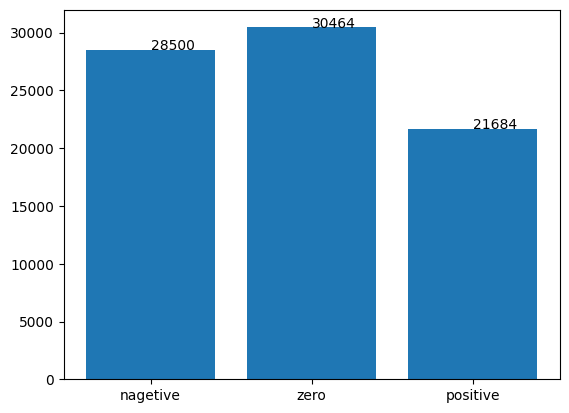

In [ ]:
import matplotlib.pyplot as plt
plt.xticks([0,1,2],['nagetive' , 'zero' , 'positive'])
plt.bar([0,1,2],[rate['nagetive'],rate['zero'],rate['positive']])
for x , data in zip([0,1,2] ,[rate['nagetive'],rate['zero'],rate['positive'] ]):
    plt.text(x , data +1 , data)
plt.show

In [ ]:
files = files_path

In [ ]:
files = [files]

In [ ]:
import torch

In [ ]:
a = torch.randint(1,9,(4,1))

In [ ]:
a

tensor([[1],
        [5],
        [2],
        [1]])

In [ ]:
torch.sum(a)

tensor(9)

In [ ]:
a = (1,2,3)

In [ ]:
a

(1, 2, 3)

In [ ]:
a[1]

2

In [1]:
import torch

In [ ]:
with torch.no_grad

In [4]:
a = torch.randint(1,9,(4,)).unsqueeze(1)

In [5]:
a

tensor([[2],
        [7],
        [2],
        [4]])

In [6]:
a.sum()

tensor(15)

In [48]:
torch.tensor([[0]]).shape

torch.Size([1, 1])

In [49]:
torch.cat((torch.tensor([[0]]),a), dim=0)

tensor([[0],
        [3],
        [8],
        [8],
        [2],
        [7],
        [4],
        [2],
        [3],
        [1],
        [4],
        [6],
        [1],
        [2],
        [8],
        [6],
        [6]])

In [50]:
a = torch.randint(1,9,(4,4))

In [51]:
a

tensor([[6, 3, 8, 1],
        [1, 2, 6, 7],
        [2, 6, 4, 5],
        [8, 3, 1, 8]])

In [53]:
b = a.max(1)# 在第几维度进行max操作

In [54]:
b[0]

tensor([8, 7, 6, 8])

In [2]:
[0,1,2,3] + [0,1,2,6,5,9]

[0, 1, 2, 3, 0, 1, 2, 6, 5, 9]